In [ ]:
#Data Cleaning and Preprocessing
#Check if there are any missing values 

import pandas as pd
import numpy as np
df=pd.read_csv('creditcard.csv')

In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


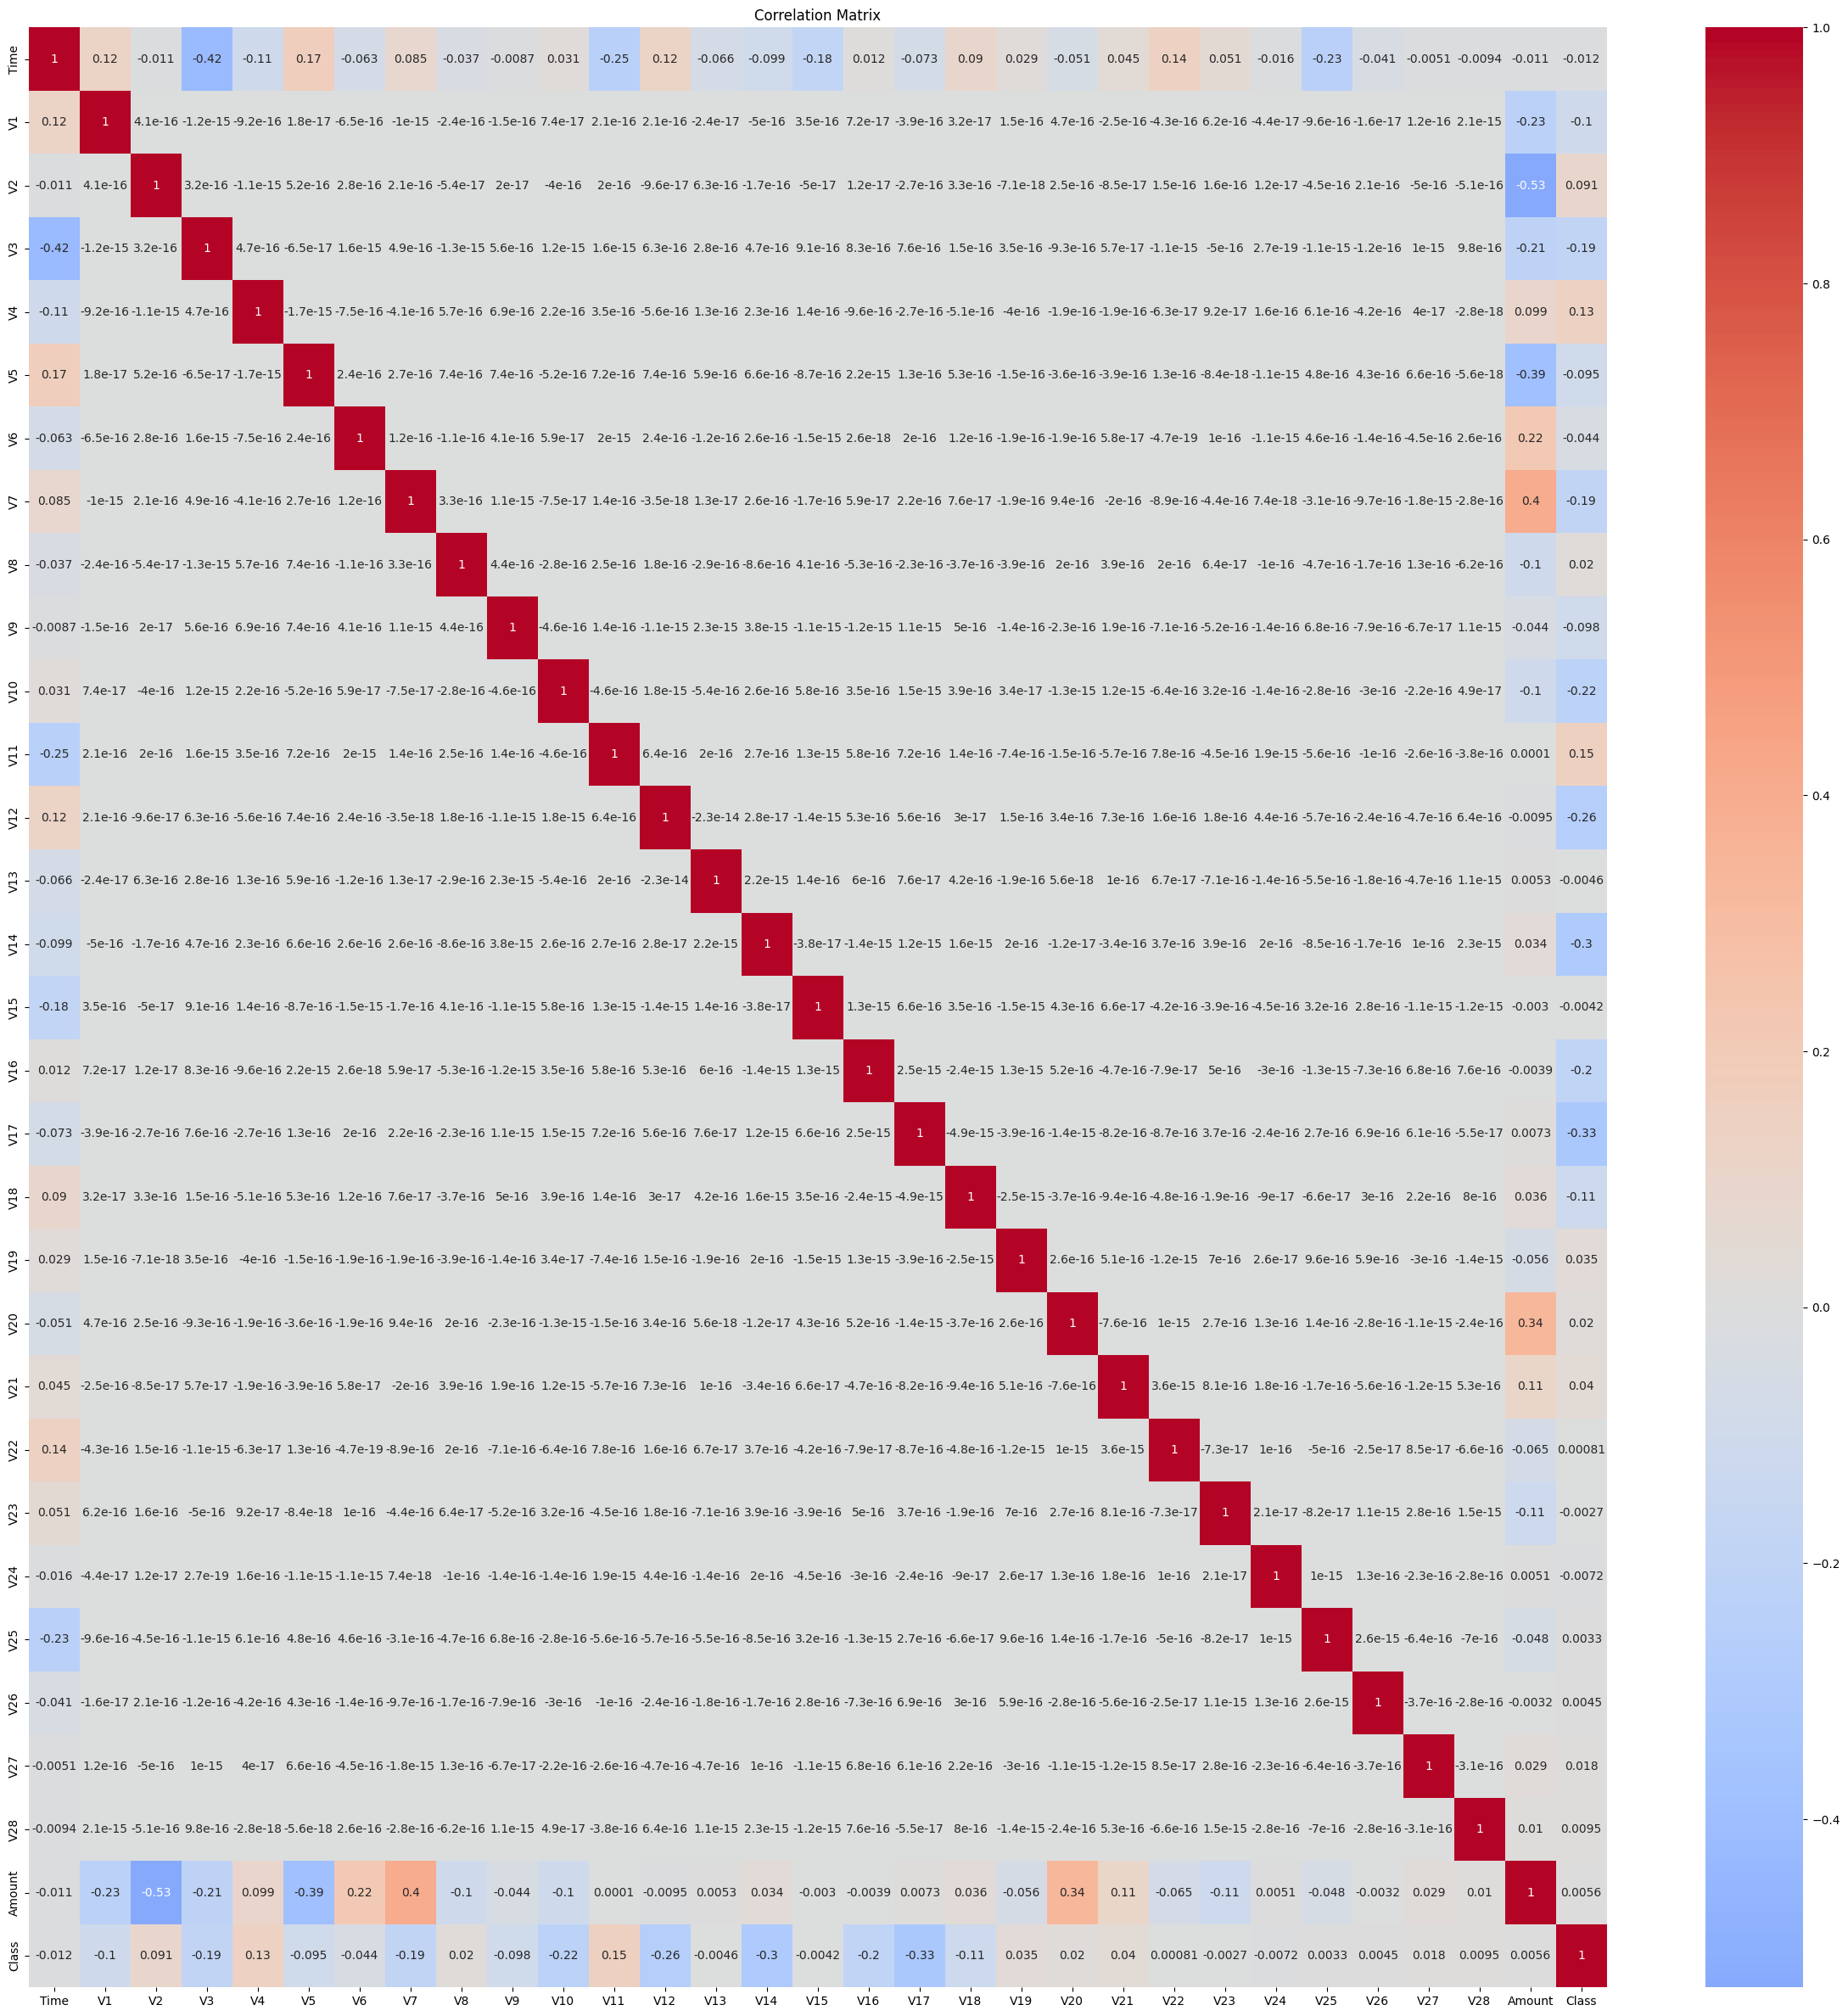

In [3]:
# visualize the correlation matrix to see which features is corelated with the Class feature

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(30, 30))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [4]:
df.drop(['Amount'],axis=1, inplace=True)
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class'],
      dtype='str')

In [5]:
# The classes are heavily skewed.
print('No Frauds: ', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds: ', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds:  99.83 % of the dataset
Frauds:  0.17 % of the dataset


In [6]:
#since this is a imbalanced dataset, we need to split the data so that we can have a balanced dataset for training and testing.
#0=No Fraud, 1=Fraud
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
# Since our classes are highly skewed we should make them equivalent in order to have a normal distribution of the classes.


# amount of fraud classes 492 rows.
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492]

fixed_df = pd.concat([fraud_df, non_fraud_df])

# Shuffle dataframe rows
new_df = fixed_df.sample(frac=1, random_state=42)

new_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
121,77.0,-0.427191,0.745708,1.761811,-0.165130,0.058298,-0.213413,0.647323,0.073464,-0.291864,...,0.052828,-0.201681,-0.432070,0.013164,0.161606,-0.401310,0.047423,0.102549,-0.116571,0
248296,153875.0,-0.613696,3.698772,-5.534941,5.620486,1.649263,-2.335145,-0.907188,0.706362,-3.747646,...,0.354773,0.319261,-0.471379,-0.075890,-0.667909,-0.642848,0.070600,0.488410,0.292345,1
239,160.0,1.171439,0.474974,0.011761,1.264303,0.116234,-0.865986,0.554393,-0.276375,-0.471302,...,-0.119439,0.070051,0.278843,-0.097491,0.426278,0.744938,-0.274728,0.008472,0.015492,0
239501,150139.0,-6.682832,-2.714268,-5.774530,1.449792,-0.661836,-1.148650,0.849686,0.433427,-1.315646,...,-1.928527,0.220526,1.187013,0.335821,0.215683,0.803110,0.044033,-0.054988,0.082337,1
143336,85285.0,-6.713407,3.921104,-9.746678,5.148263,-5.151563,-2.099389,-5.937767,3.578780,-4.684952,...,0.135711,0.954272,-0.451086,0.127214,-0.339450,0.394096,1.075295,1.649906,-0.394905,1


In [ ]:
#confirm that the new dataset are equally distributed
sns.countplot(x='Class', data=new_df, palette='Set2')
plt.title('Classes Distribution', fontsize=14)
plt.show()

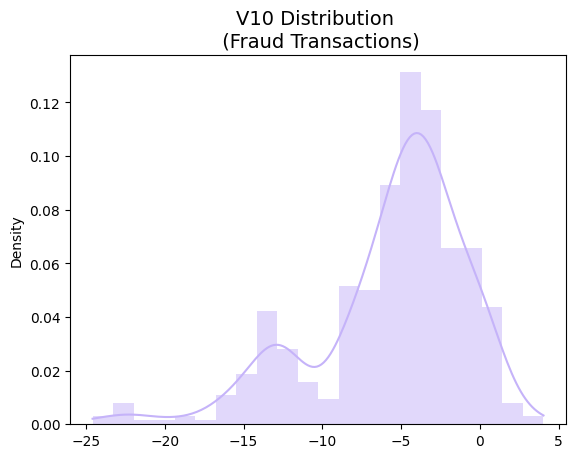

In [9]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns


# V10
v10_fraud_dist = new_df['V10'].loc[new_df['Class'] == 1].values
sns.histplot(v10_fraud_dist, kde=True, stat='density', color='#C5B3F9', linewidth=0)
plt.title('V10 Distribution \n (Fraud Transactions)', fontsize=14)

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='Class', y='V10', data=new_df, palette='Set2')
plt.title('Boxplot of V10 by Class', fontsize=14)
plt.show()

In [11]:
#remove outliers from the dataset using IQR method
import numpy as np
list=df.drop(['Time','Class'], axis=1).columns

for i in list:
    fraud=new_df[i].loc[new_df['Class']==1].values
    upper=np.percentile(fraud,75)
    lower=np.percentile(fraud,25)
    iqr=upper-lower
    acceptable_range=1.5*iqr
    upper_range=upper+acceptable_range
    lower_range=lower-acceptable_range

    new_df = new_df.drop(new_df[(new_df[i] > upper_range) | (new_df[i] < lower_range)].index)

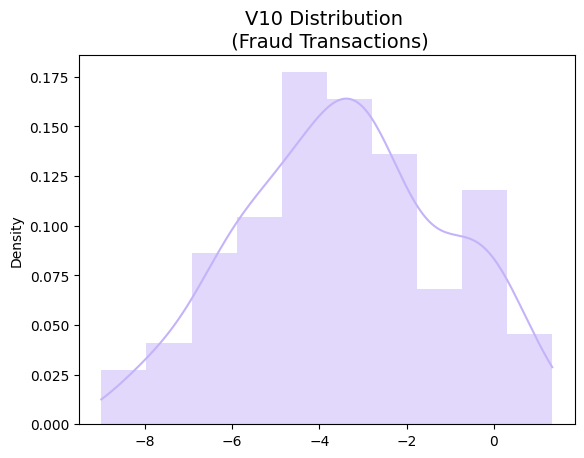

In [12]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns


# V10
v10_fraud_dist = new_df['V10'].loc[new_df['Class'] == 1].values
sns.histplot(v10_fraud_dist, kde=True, stat='density', color='#C5B3F9', linewidth=0)
plt.title('V10 Distribution \n (Fraud Transactions)', fontsize=14)

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='Class', y='V10', data=new_df, palette='Set2')
plt.title('Boxplot of V10 by Class', fontsize=14)
plt.show()

In [14]:
X=new_df.drop(['Class'], axis=1)
y=new_df['Class']

In [15]:
#check the distribution of target classes in the dataset
new_df['Class'].value_counts()

Class
0    379
1    213
Name: count, dtype: int64

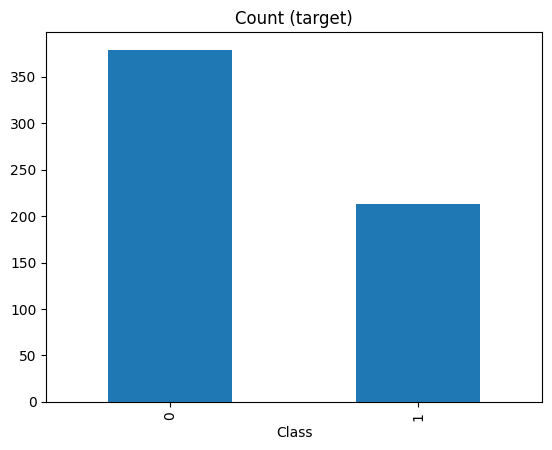

In [16]:
new_df['Class'].value_counts().plot(kind='bar', title='Count (target)');